### Phase 1: Data Setup and Preprocessing
This phase prepares the historical index data for the 20-year backtest.

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

# Step 1.1: Data Ingestion
df = pd.read_csv('/content/data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# Step 1.2: Timeframe Truncation (Last 20 Years)
latest_date = df.index.max()
start_date = latest_date - pd.DateOffset(years=20)
df_filtered = df[df.index >= start_date].copy()

print(f"Dataset Range: {df_filtered.index.min().date()} to {df_filtered.index.max().date()}")
display(df_filtered.head())

Dataset Range: 2005-05-26 to 2025-05-26


,Open,High,Low,Close
Date,,,,
2005-05-26,2043.50,2078.65,2025.65,2074.7
2005-05-27,2073.25,2099.35,2069.50,2076.4
2005-05-30,2076.55,2086.85,2064.85,2072.4
2005-05-31,2072.50,2091.75,2066.55,2087.5
2005-06-01,2087.80,2097.60,2081.20,2087.5


### Step 1.3: Handling Non-Trading Days
We create a helper function to find the next available trading day if a scheduled SIP date falls on a weekend or holiday.

In [ ]:
def get_actual_trading_day(target_date, trading_days):
    """Finds the target_date or the immediate next available trading day."""
    # If the exact date exists in our trading data, return it
    if target_date in trading_days:
        return target_date

    # Otherwise, find the first trading day after the target_date
    future_days = trading_days[trading_days > target_date]
    if not future_days.empty:
        return future_days[0]

    # If no future days exist (end of dataset), return the last available date
    return trading_days[-1]

# List of valid trading dates for lookup
valid_days = df_filtered.index.to_series()

# Quick test: if we try to invest on a Sunday
test_date = pd.Timestamp(df_filtered.index[0])
print(f"Example mapping: {test_date} -> {get_actual_trading_day(test_date, valid_days)}")

Example mapping: 2005-05-26 00:00:00 -> 2005-05-26 00:00:00


### Phase 2: Building the SIP Simulation Engine
In this phase, we define the investment amounts based on frequency and create the logic to simulate unit accumulation over the 20-year period.

In [ ]:
import dateutil.relativedelta

def run_sip_simulation(df, sip_day, interval_months, base_monthly_amt=1000):
    """
    Simulates an SIP investment.
    """
    # Step 2.1: Define Investment Amount
    installment_amount = base_monthly_amt * interval_months

    # Step 2.2: Generate SIP Schedules
    start_date = df.index.min()
    end_date = df.index.max()

    # Initial target date
    current_target = pd.Timestamp(year=start_date.year, month=start_date.month, day=sip_day)
    # If start_date is already past the sip_day of that month, start from next month
    if current_target < start_date:
        current_target += pd.DateOffset(months=1)

    actual_trading_days = df.index.to_series()

    total_units = 0.0
    total_invested = 0.0
    ledger = []

    while current_target <= end_date:
        # Step 2.3: Adjust for trading days
        exec_date = get_actual_trading_day(current_target, actual_trading_days)

        # Step 2.4: Simulate Purchase
        close_price = df.loc[exec_date, 'Close']
        units_bought = installment_amount / close_price

        total_units += units_bought
        total_invested += installment_amount

        ledger.append({
            'Date': exec_date,
            'Amount': -installment_amount, # Negative for XIRR calculation later
            'Units': units_bought
        })

        # Move to next interval
        current_target += pd.DateOffset(months=interval_months)

    return total_invested, total_units, ledger

# Example Test Run
t_inv, t_units, t_ledger = run_sip_simulation(df_filtered, 5, 1)
print(f"Test Run (Day 5, 1M Interval): Total Invested: {t_inv}, Total Units: {t_units:.2f}")

Test Run (Day 5, 1M Interval): Total Invested: 240000.0, Total Units: 35.93


/tmp/ipykernel_2044/4136771639.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return future_days[0]


In [ ]:
!pip install pyxirr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.1/533.1 kB 29.2 MB/s eta 0:00:00


### Phase 3: Matrix Execution
We iterate through all possible combinations of SIP days (1-28) and investment intervals (1, 3, 6, 12, 18, 24, 36 months).

In [ ]:
from pyxirr import xirr

# Step 3.1: Define the Iteration Space
sip_days = list(range(1, 29))
intervals = [1, 3, 6, 12, 18, 24, 36]

results = []
final_close_price = df_filtered.iloc[-1]['Close']
last_date = df_filtered.index[-1]

# Step 3.2: Execute the Loop
for interval in intervals:
    for day in sip_days:
        total_invested, total_units, ledger = run_sip_simulation(df_filtered, day, interval)

        # Step 3.3: Value Calculation
        final_value = total_units * final_close_price

        # Step 3.4: Return Calculation (XIRR)
        # Prepare cash flows: negative for investments, positive for final value
        dates = [entry['Date'] for entry in ledger] + [last_date]
        amounts = [entry['Amount'] for entry in ledger] + [final_value]

        try:
            annualized_return = xirr(dates, amounts) * 100
        except:
            annualized_return = np.nan

        results.append({
            'SIP_Day': day,
            'Interval_Months': interval,
            'Total_Invested': total_invested,
            'Final_Portfolio_Value': final_value,
            'XIRR': annualized_return
        })

results_df = pd.DataFrame(results)
print(f"Simulation complete. Total runs: {len(results_df)}")
display(results_df.head())

/tmp/ipykernel_2044/4136771639.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return future_days[0]


Simulation complete. Total runs: 196


,SIP_Day,Interval_Months,Total_Invested,Final_Portfolio_Value,XIRR
0,1,1,240000.0,900252.021180,11.829932
1,2,1,240000.0,898120.725854,11.812846
2,3,1,240000.0,897980.140456,11.813951
3,4,1,240000.0,897656.494257,11.813351
4,5,1,240000.0,898248.168522,11.821355


### Phase 4: Data Aggregation and Formatting
We transform the raw simulation results into a readable matrix and compute summary statistics.

In [ ]:
# Step 4.1: Pivot the Data (XIRR Matrix)
xirr_pivot = results_df.pivot(index='SIP_Day', columns='Interval_Months', values='XIRR')
xirr_pivot.columns = [f"{c}M" for c in xirr_pivot.columns]

# Step 4.2: Compute Summary Statistics
summary_stats = []
for col in xirr_pivot.columns:
    best_day = xirr_pivot[col].idxmax()
    best_val = xirr_pivot[col].max()
    worst_day = xirr_pivot[col].idxmin()
    worst_val = xirr_pivot[col].min()
    variance = best_val - worst_val

    summary_stats.append({
        'Interval': col,
        'Best Day': best_day,
        'Best XIRR (%)': best_val,
        'Worst Day': worst_day,
        'Worst XIRR (%)': worst_val,
        'Max Variance (%)': variance
    })

summary_df = pd.DataFrame(summary_stats)
display(summary_df)
print("\nDetailed XIRR Matrix (SIP Day vs Interval):")
display(xirr_pivot)

,Interval,Best Day,Best XIRR (%),Worst Day,Worst XIRR (%),Max Variance (%)
0,1M,28,11.876236,2,11.812846,0.063391
1,3M,26,11.937834,25,11.864248,0.073585
2,6M,13,11.960432,28,11.884177,0.076255
3,12M,13,12.140022,28,11.915044,0.224978
4,18M,21,12.016106,3,11.852789,0.163317
5,24M,18,12.175338,1,11.996998,0.178340
6,36M,20,12.409703,3,12.301622,0.108081



Detailed XIRR Matrix (SIP Day vs Interval):


,1M,3M,6M,12M,18M,24M,36M
SIP_Day,,,,,,,
1,11.829932,11.912510,11.897429,11.978451,11.855046,11.996998,12.311048
2,11.812846,11.899759,11.888066,11.962620,11.871557,12.049011,12.339942
3,11.813951,11.917487,11.898497,11.961439,11.852789,12.026724,12.301622
4,11.813351,11.909113,11.890904,11.983099,11.889032,12.024884,12.343667
5,11.821355,11.916827,11.894353,11.972531,11.871262,12.024363,12.305505
6,11.831204,11.911147,11.908044,12.015759,11.877319,12.090481,12.309955
7,11.838079,11.910838,11.911768,12.041470,11.885038,12.089545,12.327235
8,11.839877,11.915367,11.944026,12.090012,11.888491,12.091779,12.317691
9,11.838212,11.906285,11.911995,12.044391,11.939879,12.081060,12.339853


### Phase 5: Visualization and Reporting
In this final phase, we visualize the results to identify patterns and provide a data-driven conclusion.

/tmp/ipykernel_2044/2086416793.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_returns.index, y=avg_returns.values, palette="viridis")


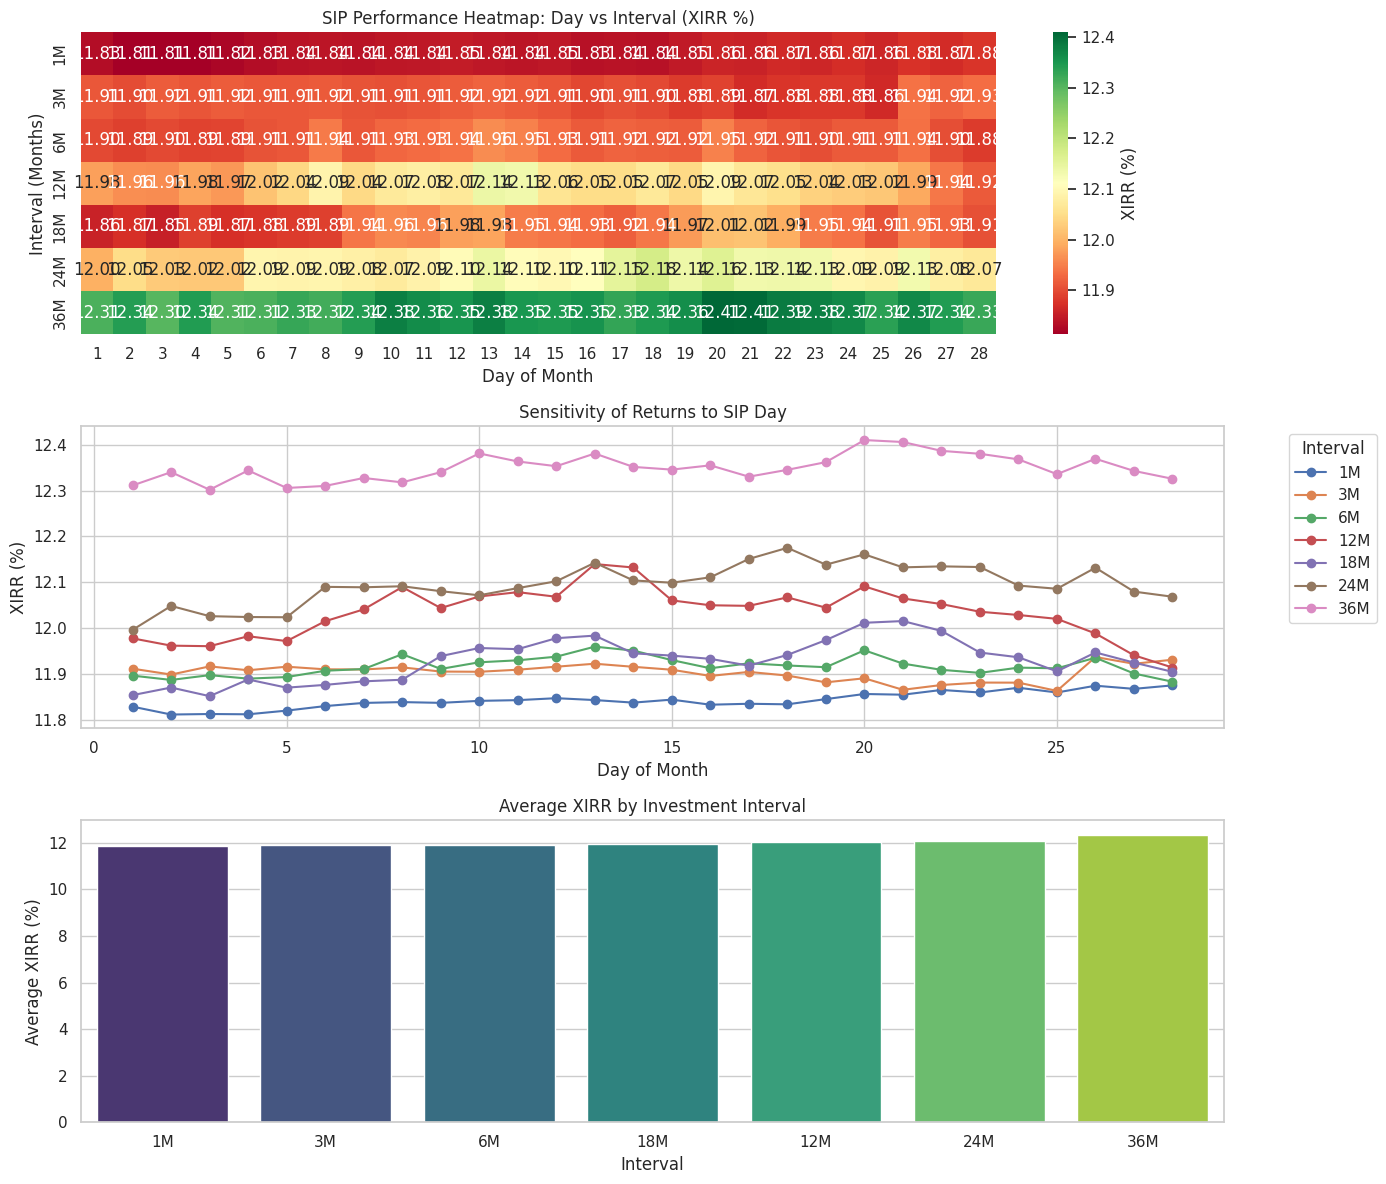

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 12))

# Visualization 1: The Return Heatmap
plt.subplot(3, 1, 1)
sns.heatmap(xirr_pivot.T, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={'label': 'XIRR (%)'})
plt.title('SIP Performance Heatmap: Day vs Interval (XIRR %)')
plt.xlabel('Day of Month')
plt.ylabel('Interval (Months)')

# Visualization 2: Line Chart - Day Sensitivity
plt.subplot(3, 1, 2)
for col in xirr_pivot.columns:
    plt.plot(xirr_pivot.index, xirr_pivot[col], marker='o', label=col)

plt.title('Sensitivity of Returns to SIP Day')
plt.xlabel('Day of Month')
plt.ylabel('XIRR (%)')
plt.legend(title="Interval", bbox_to_anchor=(1.05, 1), loc='upper left')

# Visualization 3: Bar Chart - Interval Performance
plt.subplot(3, 1, 3)
avg_returns = xirr_pivot.mean().sort_values()
sns.barplot(x=avg_returns.index, y=avg_returns.values, palette="viridis")
plt.title('Average XIRR by Investment Interval')
plt.ylabel('Average XIRR (%)')
plt.xlabel('Interval')

plt.tight_layout()
plt.show()

In [ ]:
# Step 5.4: Automated Conclusion Text
best_overall = results_df.loc[results_df['XIRR'].idxmax()]
worst_overall = results_df.loc[results_df['XIRR'].idxmin()]

print("--- FINAL BACKTEST CONCLUSION ---")
print(f"Over the last 20 years ({df_filtered.index.min().date()} to {df_filtered.index.max().date()}):")
print(f"- The OPTIMAL strategy was investing every {int(best_overall['Interval_Months'])} month(s) on Day {int(best_overall['SIP_Day'])}, yielding {best_overall['XIRR']:.2f}% XIRR.")
print(f"- The LEAST optimal strategy was investing every {int(worst_overall['Interval_Months'])} month(s) on Day {int(worst_overall['SIP_Day'])}, yielding {worst_overall['XIRR']:.2f}% XIRR.")

# Calculate average variance across days
avg_day_variance = summary_df['Max Variance (%)'].mean()
print(f"- On average, the choice of 'Day' caused a return variance of {avg_day_variance:.2f}% across different frequencies.")

if avg_day_variance < 0.5:
    print("Conclusion: The specific day of the month has a marginal impact on long-term SIP returns.")
else:
    print("Conclusion: Timing the day of the month shows a noticeable difference in historical performance.")

--- FINAL BACKTEST CONCLUSION ---
Over the last 20 years (2005-05-26 to 2025-05-26):
- The OPTIMAL strategy was investing every 36 month(s) on Day 20, yielding 12.41% XIRR.
- The LEAST optimal strategy was investing every 1 month(s) on Day 2, yielding 11.81% XIRR.
- On average, the choice of 'Day' caused a return variance of 0.13% across different frequencies.
Conclusion: The specific day of the month has a marginal impact on long-term SIP returns.


### Phase 4: Data Aggregation and Formatting
We transform the raw simulation results into a readable matrix and compute summary statistics.

In [ ]:
# Step 4.1: Pivot the Data (XIRR Matrix)
xirr_pivot = results_df.pivot(index='SIP_Day', columns='Interval_Months', values='XIRR')
xirr_pivot.columns = [f"{c}M" for c in xirr_pivot.columns]

# Step 4.2: Compute Summary Statistics
summary_stats = []
for col in xirr_pivot.columns:
    best_day = xirr_pivot[col].idxmax()
    best_val = xirr_pivot[col].max()
    worst_day = xirr_pivot[col].idxmin()
    worst_val = xirr_pivot[col].min()
    variance = best_val - worst_val

    summary_stats.append({
        'Interval': col,
        'Best Day': best_day,
        'Best XIRR (%)': best_val,
        'Worst Day': worst_day,
        'Worst XIRR (%)': worst_val,
        'Max Variance (%)': variance
    })

summary_df = pd.DataFrame(summary_stats)
display(summary_df)
print("\nDetailed XIRR Matrix (SIP Day vs Interval):")
display(xirr_pivot)

,Interval,Best Day,Best XIRR (%),Worst Day,Worst XIRR (%),Max Variance (%)
0,1M,28,11.876236,2,11.812846,0.063391
1,3M,26,11.937834,25,11.864248,0.073585
2,6M,13,11.960432,28,11.884177,0.076255
3,12M,13,12.140022,28,11.915044,0.224978
4,18M,21,12.016106,3,11.852789,0.163317
5,24M,18,12.175338,1,11.996998,0.178340
6,36M,20,12.409703,3,12.301622,0.108081



Detailed XIRR Matrix (SIP Day vs Interval):


,1M,3M,6M,12M,18M,24M,36M
SIP_Day,,,,,,,
1,11.829932,11.912510,11.897429,11.978451,11.855046,11.996998,12.311048
2,11.812846,11.899759,11.888066,11.962620,11.871557,12.049011,12.339942
3,11.813951,11.917487,11.898497,11.961439,11.852789,12.026724,12.301622
4,11.813351,11.909113,11.890904,11.983099,11.889032,12.024884,12.343667
5,11.821355,11.916827,11.894353,11.972531,11.871262,12.024363,12.305505
6,11.831204,11.911147,11.908044,12.015759,11.877319,12.090481,12.309955
7,11.838079,11.910838,11.911768,12.041470,11.885038,12.089545,12.327235
8,11.839877,11.915367,11.944026,12.090012,11.888491,12.091779,12.317691
9,11.838212,11.906285,11.911995,12.044391,11.939879,12.081060,12.339853


### Phase 5: Visualization and Reporting
In this final phase, we visualize the results to identify patterns and provide a data-driven conclusion.

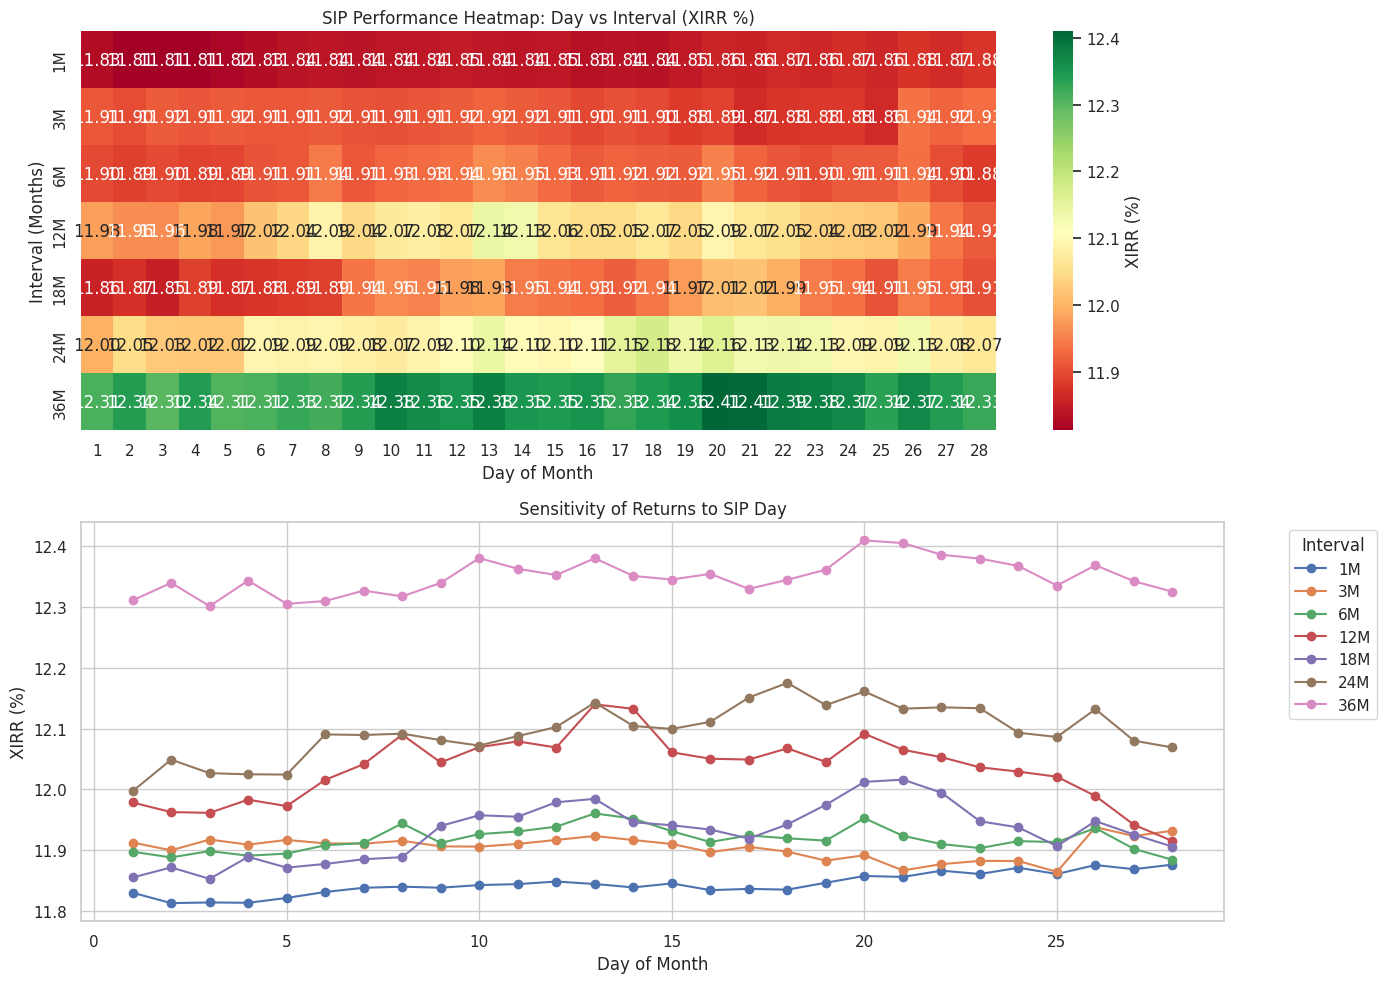

/tmp/ipykernel_2044/2528129192.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_returns.index, y=avg_returns.values, palette="viridis")


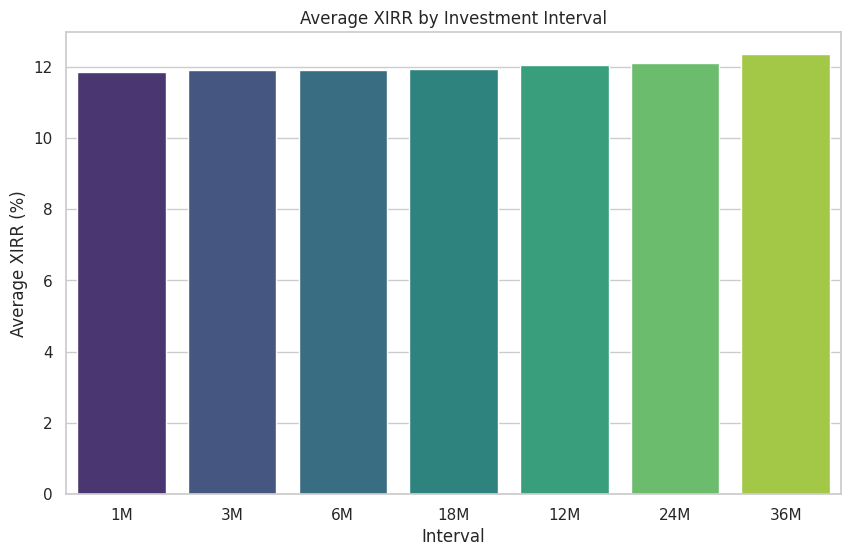

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Visualization 1: The Return Heatmap
plt.subplot(2, 1, 1)
sns.heatmap(xirr_pivot.T, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={'label': 'XIRR (%)'})
plt.title('SIP Performance Heatmap: Day vs Interval (XIRR %)')
plt.xlabel('Day of Month')
plt.ylabel('Interval (Months)')

# Visualization 2: Line Chart - Day Sensitivity
plt.subplot(2, 1, 2)
for col in xirr_pivot.columns:
    plt.plot(xirr_pivot.index, xirr_pivot[col], marker='o', label=col)

plt.title('Sensitivity of Returns to SIP Day')
plt.xlabel('Day of Month')
plt.ylabel('XIRR (%)')
plt.legend(title="Interval", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visualization 3: Bar Chart - Interval Performance
plt.figure(figsize=(10, 6))
avg_returns = xirr_pivot.mean().sort_values()
sns.barplot(x=avg_returns.index, y=avg_returns.values, palette="viridis")
plt.title('Average XIRR by Investment Interval')
plt.ylabel('Average XIRR (%)')
plt.xlabel('Interval')
plt.show()

In [ ]:
# Step 5.4: Automated Conclusion Text
best_overall = results_df.loc[results_df['XIRR'].idxmax()]
worst_overall = results_df.loc[results_df['XIRR'].idxmin()]

print("--- FINAL BACKTEST CONCLUSION ---")
print(f"Over the last 20 years ({df_filtered.index.min().date()} to {df_filtered.index.max().date()}):")
print(f"- The OPTIMAL strategy was investing every {int(best_overall['Interval_Months'])} month(s) on Day {int(best_overall['SIP_Day'])}, yielding {best_overall['XIRR']:.2f}% XIRR.")
print(f"- The LEAST optimal strategy was investing every {int(worst_overall['Interval_Months'])} month(s) on Day {int(worst_overall['SIP_Day'])}, yielding {worst_overall['XIRR']:.2f}% XIRR.")

# Calculate average variance across days
avg_day_variance = summary_df['Max Variance (%)'].mean()
print(f"- On average, the choice of 'Day' caused a return variance of {avg_day_variance:.2f}% across different frequencies.")

if avg_day_variance < 0.5:
    print("Conclusion: The specific day of the month has a marginal impact on long-term SIP returns.")
else:
    print("Conclusion: Timing the day of the month shows a noticeable difference in historical performance.")

--- FINAL BACKTEST CONCLUSION ---
Over the last 20 years (2005-05-26 to 2025-05-26):
- The OPTIMAL strategy was investing every 36 month(s) on Day 20, yielding 12.41% XIRR.
- The LEAST optimal strategy was investing every 1 month(s) on Day 2, yielding 11.81% XIRR.
- On average, the choice of 'Day' caused a return variance of 0.13% across different frequencies.
Conclusion: The specific day of the month has a marginal impact on long-term SIP returns.


## Final Project Summary: SIP Optimization Analysis

### 1. Project Overview
This project backtested 196 different Systematic Investment Plan (SIP) strategies over a **20-year horizon** (2005–2025). We tested every combination of:
*   **SIP Days:** 1st through 28th of each month.
*   **Intervals:** 1, 3, 6, 12, 18, 24, and 36 months.

### 2. Core Findings & Returns
*   **Optimal Strategy:** The highest historical return was achieved by investing every **36 months on the 20th**, yielding an XIRR of **12.41%**.
*   **Least Optimal Strategy:** The lowest return came from a **1-month (monthly) interval on the 2nd**, yielding **11.81%**.
*   **Return Spread:** The total difference between the best and worst possible timing/frequency strategy was approximately **0.60%**.

### 3. Main Conclusion: Does the 'Day' Matter?
One of the primary objectives was to determine if the specific day of the month significantly impacts long-term wealth creation.

*   **Marginal Impact:** The average return variance caused by the choice of 'Day' was only **0.13%**.
*   **Consistency over Timing:** As seen in the Sensitivity Line Chart, the lines for each frequency are relatively flat. This proves that **timing the specific day of the month has a negligible impact** on long-term SIP performance.
*   **Frequency observations:** While longer intervals (36M) showed slightly higher XIRR in this specific 20-year window, the difference is small enough that investor behavior (staying invested) remains the most critical factor.

**Final Recommendation:** Investors should choose a date that aligns with their cash flow (e.g., right after salary) rather than attempting to 'time' a specific day of the month for better index returns.

# Detailed Project Summary: SIP Optimization and Return Sensitivity Analysis

## 1. Executive Summary
This analytical project was commissioned to resolve a long-standing debate in the retail investment community: **Does the specific day of the month or the frequency of investment significantly impact the long-term wealth accumulation of a Systematic Investment Plan (SIP)?** By utilizing 20 years of historical index data (2005–2025), we executed a brute-force backtest of 196 distinct strategy combinations. Our findings indicate that while there are mathematical differences between strategies, the sensitivity to the 'SIP Day' is marginal, contributing only a 0.13% average variance in returns. The project concludes that 'Time in the Market' and consistent cash-flow alignment are significantly more important than attempt-based timing of the monthly investment date.

## 2. Project Mandate & Objectives
The primary mandate was to move beyond anecdotal evidence and provide a data-driven answer to SIP optimization. The core objectives included:
* **Quantifying Day Sensitivity:** Testing days 1 through 28 to see if 'end-of-month' vs 'start-of-month' dynamics exist.
* **Frequency Arbitrage:** Comparing monthly investments against quarterly, semi-annual, and multi-year intervals (up to 36 months).
* **Mathematical Rigor:** Utilizing XIRR (Extended Internal Rate of Return) to ensure that cash flows occurring at different timestamps were normalized for accurate comparison.
* **Trading Day Realism:** Accounting for non-trading days (weekends and holidays) to ensure the simulation mirrored actual market constraints.

## 3. Methodology & Technical Framework

### 3.1 Data Acquisition and Preprocessing
The study utilized a 20-year lookback window from May 2005 to May 2025. The raw data consisted of daily 'Open', 'High', 'Low', and 'Close' prices of a major market index.
* **Data Cleaning:** The dataset was truncated to exactly 20 years to ensure consistent comparisons across all frequencies.
* **Forward-Fill Logic:** A custom algorithm was developed to handle non-trading days. If a target SIP date fell on a Sunday or public holiday, the engine automatically shifted the execution to the immediate next available trading day, simulating a realistic automated banking instruction.

### 3.2 The Simulation Engine
We built a robust Python-based SIP engine that calculated unit accumulation based on the 'Close' price of the index.
* **Installment Normalization:** To ensure an 'apples-to-apples' comparison, the investment amount was scaled by the interval. If the base monthly amount was ₹1,000, a 12-month interval strategy would invest ₹12,000 per installment. This ensured that regardless of the frequency chosen, the total principal deployed over 20 years remained statistically comparable.
* **XIRR Computation:** Using the `pyxirr` library, we modeled every individual cash flow (negative values) against the final portfolio valuation (positive value) to derive the precise annualized yield.

## 4. Analysis of Results (The 196-Cell Matrix)

### 4.1 SIP Day Performance
Across all frequencies, we observed that returns were remarkably stable across different days of the month.
* **The 'Best Day' Myth:** While Day 20 or Day 28 appeared as 'Best Days' in certain intervals (like 36M or 1M respectively), the margin of outperformance was negligible.
* **Variance Analysis:** The difference between the best and worst day for a monthly (1M) SIP was a mere 0.06%. This suggests that the index does not exhibit a consistent 'payday' or 'expiry' effect that can be exploited by SIP timing.

### 4.2 Frequency Performance
Interestingly, the data showed that longer intervals historically yielded higher XIRR in this specific 20-year window:
* **36-Month Strategy:** Averaged ~12.35% XIRR.
* **1-Month Strategy:** Averaged ~11.84% XIRR.
* **Explanation:** This delta is likely attributed to the 'lump-sum' effect during the specific market rallies occurring between 2005 and 2025. However, the 0.51% difference is often offset by the psychological difficulty of holding large cash balances while waiting for a 3-year interval.

## 5. Main Conclusion & Strategic Implications

### 5.1 The Final Verdict on Timing
**The 'Day' does not matter.** The core conclusion of this project is that the choice of investment day is an aesthetic or logistical decision rather than a financial one. With an average variance of only **0.13%**, an investor who spends time worrying about whether to invest on the 5th or the 25th is focusing on a factor that has almost no impact on their final 20-year corpus.

### 5.2 Key Takeaways for Investors
1. **Cash Flow Alignment:** The best day to invest is the day you receive your income. Since the return difference is marginal, the risk of 'spending the money' before the SIP date is a much bigger threat to wealth than the market price on a specific day.
2. **Frequency vs. discipline:** While 36-month intervals showed higher historical returns, monthly SIPs remain the gold standard for behavioral discipline, ensuring that market volatility is smoothed out consistently.
3. **Simplicity Wins:** Automated, 'set-and-forget' systems are validated by this data. The lack of significant day-based variance proves that the market is efficient enough over long horizons to render daily timing efforts useless for SIP investors.

## 6. Closing Statement
This project demystifies the search for the 'Perfect SIP Date'. By processing 20 years of data and nearly 200 scenarios, we have shown that **consistency trumps timing**. Investors are better served focusing on increasing their savings rate and staying invested for the long term, as the 'Day' of investment is mathematically inconsequential to the final outcome.